In [1]:
options(connectionObserver = NULL)
library(limma)
library(lumi)
library(ggplot2)
library(RColorBrewer)

Loading required package: Biobase

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following object is masked from ‘package:limma’:

    plotMA


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, setdiff, sort,
    table, tapply, union, unique, unsplit, which.max, which.min


Welcome to Bioconductor

    Vignettes contain introductory material; view with
    'browseVignettes()'. To cite Bioconductor, see
    'citation("Biobase")', and for packages 'citation("pkgname")'.


Setting options('download.file.method.GEOquery'='auto')

Setting options('GEOq

In [15]:
library(bacon)

In [3]:
cobre_pd = readRDS('cobre_pd.rds')
cobre_beta = readRDS('cobre_beta_nocrosshyb.rds')
cobre_sov_res = load('cobre_final_res.Rdata')
cobre_pd$Sample_Group = relevel(factor(cobre_pd$Sample_Group), ref="control")
cobre_pd$Mat_Ethnicity = relevel(factor(cobre_pd$Mat_Ethnicity), ref="A")
cobre_pd$Pat_Ethnicity = relevel(factor(cobre_pd$Pat_Ethnicity), ref="A")
cobre_pd$Slide = as.factor(cobre_pd$Slide)
rownames(cobre_pd) = cobre_pd$Sample_Name

In [28]:
design2 = model.matrix(~ Sample_Group ,data = cobre_pd)
#fit2 = lmFit(beta2m(raw_beta), design2)
fit2 = lmFit(beta2m(cobre_beta), design2)
fit2 = eBayes(fit2)
t_stats2 <- fit2$t[,2] #random shuffled group
df2 <- fit2$df.total[1]
z_score2 = zscoreT(t_stats2, df2, approx=FALSE, method = "bailey")
bc2 <- bacon(z_score2)
limma_inflation_score2 = inflation(bc2)

In [32]:
png('Before confounder adjustment QQ.png',height=5,width=5,res=300,unit='in')
qqt(fit2$t, df=df2,
    pch=16,cex=0.2,main = paste0("Before confounder adjustment\nStudent's t Q-Q Plot\n","lambda = ",round(limma_inflation_score2,4)))
abline(0,1, col="red", lwd=2)
dev.off()

png 
  2

In [5]:
design = model.matrix(~ Sample_Group + Sex + Net_Weight_Gain + 
                        Mat_Age + Mat_Ethnicity + Pat_Ethnicity + Gravidity + Gestational_Age, 
                      data = cobre_pd) #cobre_pd #cobre_pd_cont

fit = lmFit(beta2m(cobre_beta), design)
fit = eBayes(fit)

allg.limma <- limma::topTable(fit, coef=2, n=dim(fit)[1])
sigg.limma <- subset(allg.limma, adj.P.Val < 0.05)
dim(sigg.limma)
nonsigg.limma <- subset(allg.limma, adj.P.Val >= 0.05)

[1] 15593     6

In [16]:
t_stats <- fit$t[,2] #random shuffled group
df <- fit$df.total[1]
z_score = zscoreT(t_stats, df, approx=FALSE, method = "bailey")
bc <- bacon(z_score)
limma_inflation_score = inflation(bc)

In [33]:
png('After confounder adjustment QQ.png',height=5,width=5,res=300,unit='in')
qqt(fit$t, df=fit$df.prior+fit$df.residual,
    pch=16,cex=0.2,main = paste0("After confounder adjustment\nStudent's t Q-Q Plot\n","lambda = ",round(limma_inflation_score,4)))
abline(0,1, col="red", lwd=2)
dev.off()

png 
  2

In [55]:
#Reassess Genomic Inflation: λ Calculation
#λ = 1.28 is moderate inflation. Compare this to empirical null distributions:
#Shuffle group labels to create a null model.
#Check whether the observed inflation exceeds null expectations.
# Shuffle group labels
set.seed(456)
cobre_pd$Group_shuffled <- sample(cobre_pd$Sample_Group)

# Run limma with shuffled groups
mod_shuffled <- model.matrix(~ Group_shuffled+ Sex + Net_Weight_Gain + 
                        Mat_Age + Mat_Ethnicity + Pat_Ethnicity + Gravidity + Gestational_Age, data = cobre_pd)
#adjusted lambda = 1.162183

#mod_shuffled <- model.matrix(~ Group_shuffled, data = cobre_pd)#43.44374
fit_shuffled <- lmFit(cobre_beta, mod_shuffled)
fit_shuffled <- eBayes(fit_shuffled)

# Compare lambda
#lambda_null <- median(fit_shuffled$t^2) / qchisq(0.5, df = 1)
#print(lambda_null)
t_stats <- fit_shuffled$t[,2] #random shuffled group
df <- fit_shuffled$df.total[1]
z_score = zscoreT(t_stats, 57, approx=FALSE, method = "bailey")
bc <- bacon(z_score)
bc
inflation(bc)
bias(bc)

Bacon-object containing 1 set(s) of 410765 test-statistics.
...estimated bias: 0.028.
...estimated inflation: 0.96.

Empirical null estimates are based on 5000 iterations with a burnin-period of 2000.

sigma.0 
0.9643662

mu.0 
0.02802137

In [30]:
#sva
library(sva)
mod = model.matrix(~as.factor(Sample_Group), data=cobre_pd)
mod0 = model.matrix(~1,data=cobre_pd)
n.sv = num.sv(cobre_beta,mod,method="leek")
n.sv

[1] 0

In [56]:
mod = model.matrix(~ Sample_Group + Sex + Net_Weight_Gain + 
                        Mat_Age + Mat_Ethnicity + Pat_Ethnicity + Gravidity + Gestational_Age+Parity, 
                      data = cobre_pd)
mod0 = model.matrix(~as.factor(Sample_Group),data=cobre_pd)
n.sv = num.sv(cobre_beta,mod,method="leek")
n.sv

[1] 0

In [57]:
svobj = sva(cobre_beta,mod,mod0,n.sv=n.sv)

Warning message in sva(cobre_beta, mod, mod0, n.sv = n.sv):
“Returning zero surrogate variables as requested”


In [59]:
pValues = f.pvalue(cobre_beta,mod,mod0)
qValues = p.adjust(pValues,method="BH")
modSv = cbind(mod,svobj$sv)
mod0Sv = cbind(mod0,svobj$sv)
pValuesSv = f.pvalue(cobre_beta,modSv,mod0Sv)
qValuesSv = p.adjust(pValuesSv,method="BH")

In [62]:
modSv[1:5,]

,(Intercept),Sample_Groupobese,SexM,Net_Weight_Gain,Mat_Age,Mat_EthnicityC,Mat_EthnicityNHPI,Pat_EthnicityC,Pat_EthnicityNHPI,Gravidity2,Gravidity3,Gravidity4,Gravidity5,GravidityMore,Gestational_Age,Parity1,Parity2,ParityMore
MT11,1,0,0,29,37,0,0,0,0,0,1,0,0,0,39,0,1,0
MT12,1,0,0,20,17,0,1,0,1,0,0,0,0,0,39,0,0,0
MT13,1,1,0,27,28,1,0,0,1,0,0,1,0,0,39,0,1,0
MT14,1,0,1,25,38,0,0,1,0,0,0,1,0,0,38,1,0,0
MT16,1,1,0,23,33,0,1,0,1,0,0,1,0,0,39,0,0,1


In [61]:
fit = lmFit(cobre_beta,modSv)

ERROR: Error in eval(expr, envir, enclos): object 'edata' not found


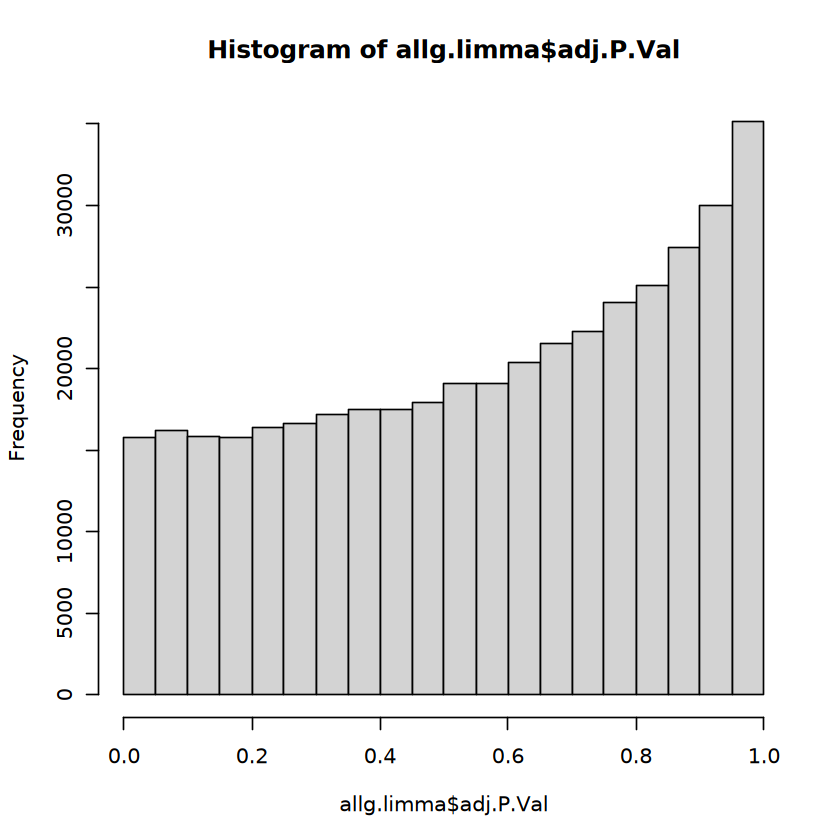

In [32]:
hist(allg.limma$adj.P.Val)

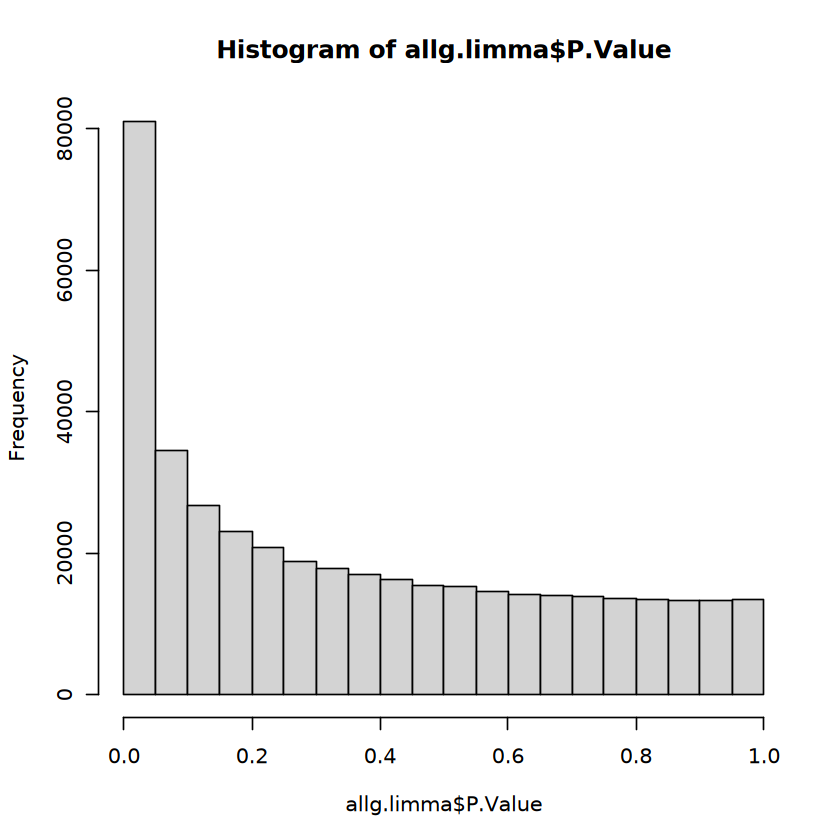

In [34]:
hist(allg.limma$P.Value)

In [33]:
dim(sigg.limma)
allg.limma[1:5,]

[1] 15800     6

,logFC,AveExpr,t,P.Value,adj.P.Val,B
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
cg25326283,0.8380447,-5.489810,7.827731,1.132669e-10,4.064661e-05,13.68342
cg00585558,0.8160665,-4.472824,7.683998,1.979069e-10,4.064661e-05,13.17953
cg16927136,1.5297949,-6.376763,7.529028,3.613627e-10,4.947838e-05,12.63515
cg06805542,1.1148529,-6.437697,7.442291,5.062200e-10,5.198437e-05,12.33006
cg01937701,1.5840882,-4.400233,7.354444,7.122266e-10,5.851155e-05,12.02083


In [64]:
pca <- prcomp(t(cobre_beta), center = TRUE, scale. = TRUE)  # beta_values = CpG methylation matrix
pcs <- as.data.frame(pca$x) 

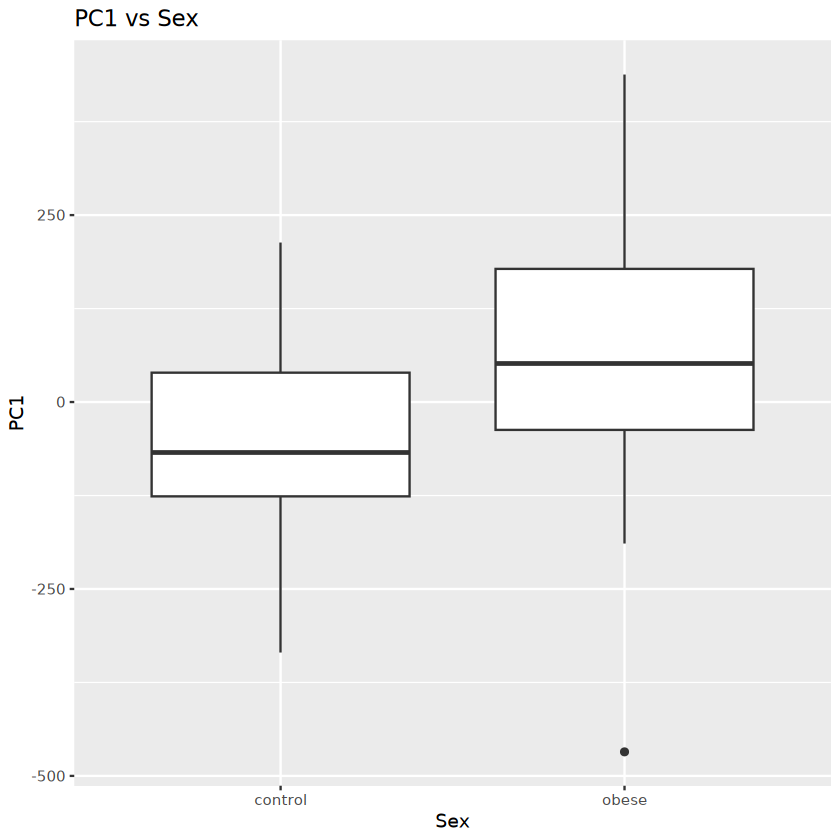

In [65]:
library(ggplot2)
pheno = cobre_pd
pheno$PC1 <- pcs$PC1
pheno$PC2 <- pcs$PC2
pheno$PC3 <- pcs$PC3 
# Boxplot of PC1 by sex
ggplot(pheno, aes(x = Sample_Group, y = PC1)) +
  geom_boxplot() +
  labs(title = "PC1 vs Sex", x = "Sex", y = "PC1")

In [6]:
colnames(fit$coef)

[1] "(Intercept)"       "Sample_Groupobese" "SexM"             
 [4] "Net_Weight_Gain"   "Mat_Age"           "Mat_EthnicityC"   
 [7] "Mat_EthnicityNHPI" "Pat_EthnicityC"    "Pat_EthnicityNHPI"
[10] "Gravidity2"        "Gravidity3"        "Gravidity4"       
[13] "Gravidity5"        "GravidityMore"     "Gestational_Age"  
[16] "Parity1"           "Parity2"           "ParityMore"       
[19] "Hemoglobin"

In [23]:
allg.limma21 <- limma::topTable(fit, coef=21, n=dim(fit)[1])
sigg.limma21 <- subset(allg.limma21, adj.P.Val < 0.05)
dim(sigg.limma21)
allg.limma22 <- limma::topTable(fit, coef=22, n=dim(fit)[1])
sigg.limma22 <- subset(allg.limma22, adj.P.Val < 0.05)
dim(sigg.limma22)

[1] 0 6

[1] 0 6

In [7]:
p_values1 = allg.limma$P.Value
p_values2 = allg.limma$adj.P.Val

In [85]:
allg.limma$bacon_adj_p = p.adjust(allg.limma$bacon_p, method = "BH")

In [98]:
allg.limma$bh_adj_p = p.adjust(allg.limma$P.Value, method = "BH")
dim(allg.limma[allg.limma$bh_adj_p<0.05,])

[1] 15668    11

In [89]:
significant_results <- allg.limma[allg.limma$bacon_adj_p < 0.05 & allg.limma$adj.P.Val < 0.05, ]

In [94]:
library(dplyr)

# Assuming allg.limma is your data frame
significant_results <- allg.limma %>%
  filter(bacon_p < 0.05 & adj.P.Val < 0.05)

dim(significant_results)

Warning message:
“Using one column matrices in `filter()` was deprecated in dplyr 1.1.0.
ℹ Please use one dimensional logical vectors instead.”


[1] 15668    10

In [97]:
sum(allg.limma$P.Value<0.05)
sum(allg.limma$bacon_p<0.05)

[1] 80729

[1] 39567

In [72]:
dim(allg.limma[allg.limma$bacon_p<0.05,])
dim(allg.limma[allg.limma$bacon_q<0.05,])
dim(allg.limma[allg.limma$bacon_adj.p<0.05,])

[1] 37934    10

[1]  0 10

[1]  0 10

In [100]:
anno = readRDS('anno_450k.rds')

In [102]:
anno_promoter = anno[anno$UCSC_RefGene_Group%in%c('TSS200','TSS1500'),]

In [106]:
allg_promoter = allg.limma[rownames(allg.limma)%in%rownames(anno_promoter),]

In [108]:
dim(allg_promoter)

[1] 106528     11

In [109]:
allg_promoter[1:5,]

,logFC,AveExpr,t,P.Value,adj.P.Val,B,bacon_p,bacon_adj_p,bacon_p2,bacon_q,bh_adj_p
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,"<dbl[,1]>",<dbl>,"<dbl[,1]>","<dbl[,1]>",<dbl>
cg25326283,0.8507128,-5.489810,8.118291,2.606432e-11,1.070631e-05,14.99793,3.555667e-07,0.1220361,4.169322e-06,0.1240114,1.070631e-05
cg00585558,0.8180865,-4.472824,7.900272,6.203941e-11,1.274181e-05,14.21653,5.941894e-07,0.1220361,5.944575e-06,0.1240114,1.274181e-05
cg01937701,1.5918590,-4.400233,7.611617,1.958140e-10,2.451384e-05,13.17852,1.174643e-06,0.1308343,9.582563e-06,0.1247521,2.451384e-05
cg16927136,1.5074665,-6.376763,7.561878,2.387140e-10,2.451384e-05,12.99937,1.321197e-06,0.1308343,1.041346e-05,0.1247521,2.451384e-05
cg11141075,0.6524976,-4.450596,7.269220,7.654584e-10,5.603927e-05,11.94419,2.640034e-06,0.1308343,1.707256e-05,0.1247521,5.603927e-05


In [115]:
allg_promoter$bacon_bh_adj = p.adjust(allg_promoter$bacon_p, method = "BH") #4
allg_promoter[1:5,]

,logFC,AveExpr,t,P.Value,adj.P.Val,B,bacon_p,bacon_adj_p,bacon_p2,bacon_q,bh_adj_p,bacon_bh_adj
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,"<dbl[,1]>",<dbl>,"<dbl[,1]>","<dbl[,1]>",<dbl>,<dbl>
cg25326283,0.8507128,-5.489810,8.118291,2.606432e-11,1.070631e-05,14.99793,3.555667e-07,0.1220361,4.169322e-06,0.1240114,1.070631e-05,0.03164891
cg00585558,0.8180865,-4.472824,7.900272,6.203941e-11,1.274181e-05,14.21653,5.941894e-07,0.1220361,5.944575e-06,0.1240114,1.274181e-05,0.03164891
cg01937701,1.5918590,-4.400233,7.611617,1.958140e-10,2.451384e-05,13.17852,1.174643e-06,0.1308343,9.582563e-06,0.1247521,2.451384e-05,0.03518611
cg16927136,1.5074665,-6.376763,7.561878,2.387140e-10,2.451384e-05,12.99937,1.321197e-06,0.1308343,1.041346e-05,0.1247521,2.451384e-05,0.03518611
cg11141075,0.6524976,-4.450596,7.269220,7.654584e-10,5.603927e-05,11.94419,2.640034e-06,0.1308343,1.707256e-05,0.1247521,5.603927e-05,0.05156949
